Age的P值： 0.9788032525063932
LN(-)和LN(+)两组的Age直方图:


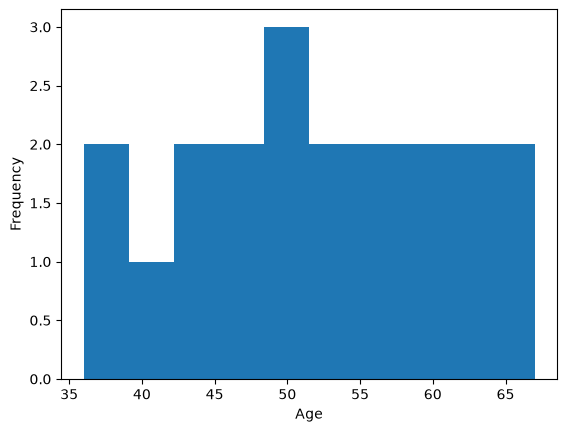

LN(-)和LN(+)两组的AgeQ-Q图：


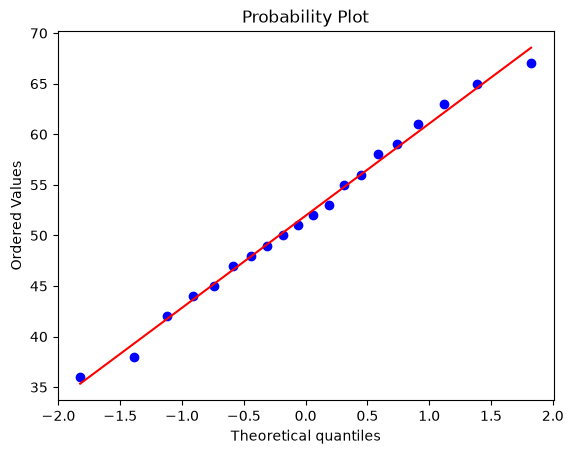

age符合正态分布
-----------
Tumor_Size的P值: 0.9162922826518878
LN(-)和LN(+)两组的Tumor_Size直方图:


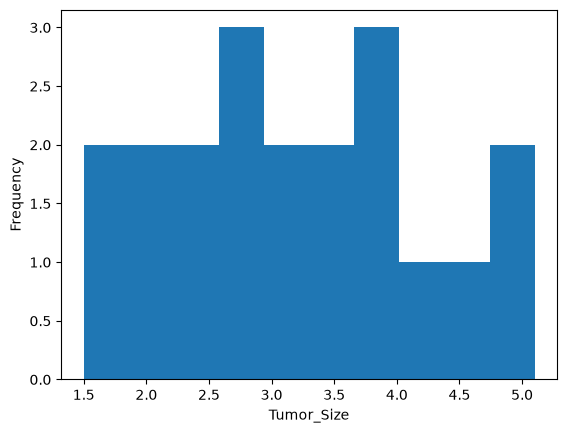

LN(-)和LN(+)两组的Tumor_Size Q-Q图：


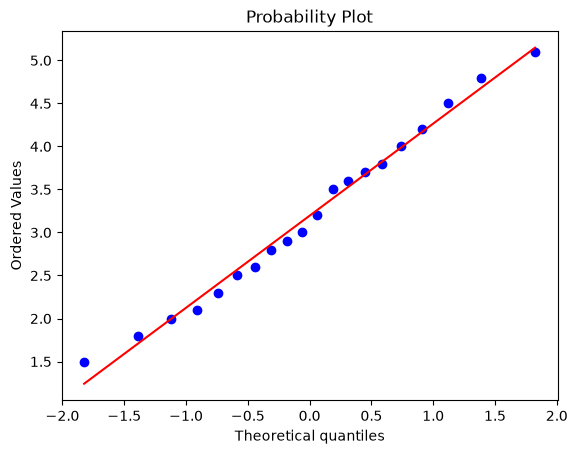

Tumor_Size符合正态分布
----------
Ki67的P值: 0.002156689932776424
LN(-)和LN(+)两组的Ki67直方图:


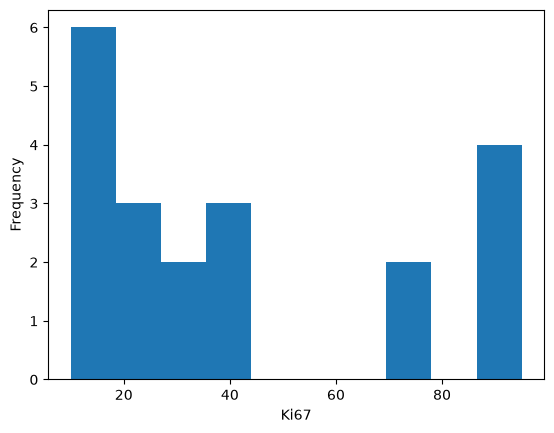

Ki67不符合正态分布
----------
LN(-)组：
             Age  Tumor_Size       Ki67   ER        PR  HER2  Lymph_Node
count   8.000000    8.000000   8.000000  8.0  8.000000   8.0         8.0
mean   43.750000    2.200000  36.875000  1.0  0.875000   0.0         0.0
std     4.862392    0.434248  34.115089  0.0  0.353553   0.0         0.0
min    36.000000    1.500000  10.000000  1.0  0.000000   0.0         0.0
25%    41.000000    1.950000  13.750000  1.0  1.000000   0.0         0.0
50%    44.500000    2.200000  20.000000  1.0  1.000000   0.0         0.0
75%    47.250000    2.525000  52.500000  1.0  1.000000   0.0         0.0
max    50.000000    2.800000  90.000000  1.0  1.000000   0.0         0.0
LN(+)组：
             Age  Tumor_Size       Ki67         ER         PR       HER2  \
count  12.000000   12.000000  12.000000  12.000000  12.000000  12.000000   
mean   57.416667    3.858333  44.166667   0.416667   0.166667   0.750000   
std     5.759709    0.693421  30.735923   0.514929   0.389249   0.452267   


In [10]:
import pandas as pd
df=pd.read_csv('breast_cancer_clinical2.csv')
import scipy
from scipy.stats import shapiro
stat,p=shapiro(df['Age'])
print('Age的P值：',p)
print('LN(-)和LN(+)两组的Age直方图:')
import matplotlib.pyplot as plt
plt.hist(df['Age'],bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
print('LN(-)和LN(+)两组的AgeQ-Q图：')
import scipy.stats as stats
import matplotlib.pyplot as plt
stats.probplot(df['Age'],dist='norm',plot=plt)
plt.show()
print('age符合正态分布')
print('-----------')
stat,p=shapiro(df['Tumor_Size'])
print('Tumor_Size的P值:',p)
print('LN(-)和LN(+)两组的Tumor_Size直方图:')
plt.hist(df['Tumor_Size'],bins=10)
plt.xlabel('Tumor_Size')
plt.ylabel('Frequency')
plt.show()
print('LN(-)和LN(+)两组的Tumor_Size Q-Q图：')
stats.probplot(df['Tumor_Size'],dist='norm',plot=plt)
plt.show()
print('Tumor_Size符合正态分布')
print('----------')
stat,p=shapiro(df['Ki67'])
print('Ki67的P值:',p)
print('LN(-)和LN(+)两组的Ki67直方图:')
plt.hist(df['Ki67'],bins=10)
plt.xlabel('Ki67')
plt.ylabel('Frequency')
plt.show()
print('Ki67不符合正态分布')
print('----------')
print('LN(-)组：')
group0=df[df['Lymph_Node']==0]
print(group0.describe())
print('LN(+)组：')
group1=df[df['Lymph_Node']==1]
print(group1.describe())
print('Age和Tumor_Size的T_test:')
import scipy
from scipy.stats import ttest_ind
t,p=ttest_ind(group0['Age'],group1['Age'],equal_var=False)
print('Age的t值：',t)
print('Age的p值：',p)
t,p=ttest_ind(group0['Tumor_Size'],group1['Tumor_Size'],equal_var=False)
print('Tumor_Size的t值:',t)
print('Tumor_Size的p值：',p)
table1=pd.DataFrame({
    'Variable':['Age','Tumor_Size'],
    'LN(-)':['43.75±4.86','2.2±0.43'],
    'LN(+)':['57.42±5.76','3.86±0.69'],
    't value':[-5.71,-6.57],
    'p value':['p<0.05','p<0.05']
})
print(table1)
table1.to_excel('T-test Results.xlsx')
print('----------')
print('Ki67的mann whitney U test:')
import scipy
from scipy.stats import mannwhitneyu
u,p=mannwhitneyu(group0['Ki67'],group1['Ki67'],alternative='two-sided')
print('Ki67的u值：',u)
print('Ki67的p值：',p)
table2=pd.DataFrame({
    'Variable':['Ki67'],
    'LN(-)':['20(13.75,52.5)'],
    'LN(+)':['35(18.75,70)'],
    'U':[37],
    'P':[0.41]
})
print(table2)
table2.to_excel('Mann-Whitney U Test Results.xlsx')



